### Use this script to get all the averages and standard deviations of the Hamner data. 

In [3]:
import os
import pandas as pd
import numpy as np
os.add_dll_directory('C:/Users/jonstingel/opensim-core-4.5.1-2024-08-23-cf3ef35/bin')
import opensim as osim
import pdb

currentdir = os.getcwd(); print(currentdir)
Hamnerdir = currentdir + '\\..\\HamnerData\\'; print(Hamnerdir)

# get all the folder names in the hamner directory
folders = os.listdir(Hamnerdir); # print(folders)
# trim folders to only those that don't include .zip, and don't have '_
folders = [f for f in folders if '.zip' not in f and '_' not in f]; print(folders)

subjectmass = {
    'subject01': 72.84000000,
    'subject02': 76.47567358,
    'subject03': 64.00188341,
    'subject04': 80.46728644,
    'subject08': 82.37237439,
    'subject10': 69.26355490,
    'subject11': 69.35427337 ,
    'subject17': 68.44708860,
    'subject19': 65.13586433,
    'subject20': 67.17703
}

c:\Users\jonstingel\code\predictiveSim\testingMaterials\PredictRunning_2d
c:\Users\jonstingel\code\predictiveSim\testingMaterials\PredictRunning_2d\..\HamnerData\
['subject01', 'subject02', 'subject03', 'subject04', 'subject08', 'subject10', 'subject11', 'subject17', 'subject19', 'subject20']


In [ ]:
# create some dictionaries to store the data
count = 0
kinematics = {}
moments = {}
grfs = {}
durations = {}

# loop through the subjects folders
for subj in folders:
    print('\n')
    subjectdir = Hamnerdir + subj + '\\'; print(subjectdir)
    # get the files in the subject directory
    subjfiles = os.listdir(subjectdir); # print(subjfiles)
    # get rid of any files that don't have 'cmc' in them
    subjfiles = [f for f in subjfiles if 'cmc' in f]; print(subjfiles)
    
    # intermediate subject dictionaries
    subjkinematics = {}
    subjmoments = {}
    subjgrfs = {}
    subjdurations = {}
    count += 1

    for each in subjfiles:
        cmcdir = subjectdir + each + '\\'; print(cmcdir)
        # gather the CMC folders
        cmcfiles = os.listdir(cmcdir); # print(cmcfiles)
        # get rid of anything that isn't the actual CMC results folder
        cmcfiles = [f for f in cmcfiles if 'Run_4' in f]; # print(cmcfiles)
        for speed in cmcfiles:
            cmcresultsdir = cmcdir + speed + '\\'; # print(cmcresultsdir)
            # get the files in the CMC results directory
            cmcresultsfiles = os.listdir(cmcresultsdir); # print(cmcresultsfiles)
            # get rid of the files that have 'xml' in them, and don't have Run_4 in them
            cmcresultsfiles = [f for f in cmcresultsfiles if 'xml' not in f and 'Run_4' in f and 'log' not in f]; print(cmcresultsfiles)
            for trial in cmcresultsfiles:
                cmccycledir = cmcresultsdir + trial + '\\'; # print(cmccycledir)
                # get the files in the CMC cycle directory
                cmccyclefiles = os.listdir(cmccycledir); # print(cmccyclefiles)
                
                ## start with getting the kinematics data
                kinfiles = [f for f in cmccyclefiles if 'Kinematics_q' in f]; print(kinfiles)
                cyclekin = osim.TimeSeriesTable(cmccycledir + kinfiles[0])
                # get the joint angles
                jointangles = cyclekin.getColumnLabels()
                time = cyclekin.getIndependentColumn()
                inittime = time[0]
                finaltime = time[-1]
                for coord in jointangles:
                    # get the data column and interpolate it to 1000 points
                    data = cyclekin.getDependentColumn(coord).to_numpy()
                    # interpolate the data to 1000 points
                    newtime = np.linspace(time[0], time[-1], 1000)
                    if 'time' not in subjkinematics.keys():
                        subjkinematics['time'] = np.linspace(0, 100, 1000)
                    else:
                        subjkinematics['time'] = np.column_stack((subjkinematics['time'], np.linspace(0, 100, 1000)))
                    newdata = np.interp(newtime, time, data)
                    # if 'pelvis_ty' in coord or 'pelvis_tx' in coord or 'pelvis_tz' in coord:
                        # newdata = newdata / # insert subject heights here
                    # add the data to the dictionary
                    # if the label isnt i the subject kinematics dictionary, add it
                    if coord not in subjkinematics.keys():
                        subjkinematics[coord] = newdata
                    else:
                        # add another column to the existing array
                        subjkinematics[coord] = np.column_stack((subjkinematics[coord], newdata))

                ## load in the GRF file. 
                grffiles = os.listdir(subjectdir + '\\ExportedData\\'); #print(grffiles)
                grffile = [f for f in grffiles if 'Run_400' in f and 'newCOP3' in f and 'v24' in f]; print(grffile)
                grfdata = osim.TimeSeriesTable(subjectdir + '\\ExportedData\\' + grffile[0])
                # get the labels
                grflabels = grfdata.getColumnLabels()
                grfdata.trim(inittime, finaltime)
                grfy = grfdata.getDependentColumn('R_ground_force_vy').to_numpy()
                grfx = grfdata.getDependentColumn('R_ground_force_vx').to_numpy()
                grftime = grfdata.getIndependentColumn()

                # should be able to grab the time from the grf data
                timeinit = grftime[0]
                timefinal = grftime[-1]
                totduration = timefinal - timeinit
                # if 'duration' not in subjdurations.keys():
                #     subjdurations['duration'] = totduration
                # else:
                if 'duration' not in subjdurations.keys():
                    subjdurations['duration'] = [totduration]
                else:
                    subjdurations['duration'].append(totduration)

                # resample the data to 1000 points
                newgrftime = np.linspace(grftime[0], grftime[-1], 1000)
                if 'time' not in subjgrfs.keys():
                    subjgrfs['time'] = np.linspace(0, 100, 1000)
                else:
                    subjgrfs['time'] = np.column_stack((subjgrfs['time'], np.linspace(0, 100, 1000)))
                newgrfy = np.interp(newgrftime, grftime, grfy) / (subjectmass[subj] * 9.81)
                newgrfx = np.interp(newgrftime, grftime, grfx) / (subjectmass[subj] * 9.81)
                # add the data to the dictionary
                if 'ground_force_vy' not in subjgrfs.keys():
                    subjgrfs['ground_force_vy'] = newgrfy
                    subjgrfs['ground_force_vx'] = newgrfx
                else:
                    subjgrfs['ground_force_vy'] = np.column_stack((subjgrfs['ground_force_vy'], newgrfy))
                    subjgrfs['ground_force_vx'] = np.column_stack((subjgrfs['ground_force_vx'], newgrfx))
                
    # TODO: now have to figure out which files I actually want to use for moments.
    ## do the moments as well.
    subjagainfiles = os.listdir(subjectdir); # print(subjagainfiles)
    subjagainfiles = [f for f in subjagainfiles if 'rra' in f]; # print(subjagainfiles)
    for again in subjagainfiles:
        againdir = subjectdir + again + '\\'; # print(againdir)
        againfiles = os.listdir(subjectdir + again); # print(againfiles)
        againfiles = [f for f in againfiles if 'Run_4' in f]; # print(againfiles)
        for rraspeed in againfiles:
            rradir = subjectdir + again + '\\' + rraspeed + '\\'; # print(rradir)
            rrafiles = os.listdir(rradir);
            rrafiles = [f for f in rrafiles if 'xml' not in f and 'log' not in f and 'osim' not in f]; # print(rrafiles)
            for rracycle in rrafiles:
                rracycledir = rradir + rracycle + '\\'; # print(rracycledir)
                # get the files in the RRA cycle directory
                rrafiles = os.listdir(rracycledir);
                rrafiles = [f for f in rrafiles if 'Run_4' in f and 'Actuation_force' in f]; print(rrafiles)
                # load the actuator file from the RRA results
                actuatordata = osim.TimeSeriesTable(rracycledir + rrafiles[0])
                # get the labels
                actuatorlabels = actuatordata.getColumnLabels()
                actuatortime = actuatordata.getIndependentColumn()
                # get the actuator data loop through all of them and save
                for actuator in actuatorlabels:
                    act = actuatordata.getDependentColumn(actuator).to_numpy()
                    # interpolate the data to 1000 points
                    newacttime = np.linspace(actuatortime[0], actuatortime[-1], 1000)
                    if 'time' not in subjmoments.keys():
                        subjmoments['time'] = np.linspace(0, 100, 1000)
                    else:
                        subjmoments['time'] = np.column_stack((subjmoments['time'], np.linspace(0, 100, 1000)))
                    newact = np.interp(newacttime, actuatortime, act) / subjectmass[subj]
                    # add the data to the dictionary
                    if actuator not in subjmoments.keys():
                        subjmoments[actuator] = newact
                    else:
                        subjmoments[actuator] = np.column_stack((subjmoments[actuator], newact))
    ## back at the subject level, we need to take means across subjects, and save them to the larger dictionary
    # for each of the keys in the kinematics dictionary, take the mean across subjects
    for each in subjkinematics.keys():
        if each not in kinematics.keys():
            if each == 'time':
                kinematics[each] = subjkinematics[each]
            kinematics[each] = (np.mean(subjkinematics[each], axis=1)).reshape(1000, 1)
        else:
            kinematics[each] = np.column_stack((kinematics[each], (np.mean(subjkinematics[each], axis=1)).reshape(1000, 1)))
    # for each of the keys in the moments dictionary, take the mean across subjects
    for each in subjmoments.keys():
        if each not in moments.keys():
            moments[each] = (np.mean(subjmoments[each], axis=1)).reshape(1000, 1)
        else:
            moments[each] = np.column_stack((moments[each], (np.mean(subjmoments[each], axis=1)).reshape(1000, 1)))
    # for each of the keys in the grfs dictionary, take the mean across subjects
    for each in subjgrfs.keys():
        if each not in grfs.keys():
            grfs[each] = (np.mean(subjgrfs[each], axis=1)).reshape(1000, 1)
        else:
            grfs[each] = np.column_stack((grfs[each], (np.mean(subjgrfs[each], axis=1)).reshape(1000, 1)))
    
    # for each of the keys in the durations dictionary, take the mean across subjects
    for each in subjdurations.keys():
        if each not in durations.keys():
            durations['avg'] = [np.mean(subjdurations[each])]
            durations['stdev'] = [np.std(subjdurations[each])]
            durations['duration'] = subjdurations[each]
        else:
            durations['avg'].append(np.mean(subjdurations[each]))
            durations['stdev'].append(np.std(subjdurations[each]))
            durations['duration'] = np.vstack((durations['duration'], np.array(subjdurations[each]).reshape(1, 3)))

print('okay should be done now...')
print(durations)




c:\Users\jonstingel\code\predictiveSim\testingMaterials\PredictRunning_2d\..\HamnerData\subject01\
['cmc_multipleSteps_v24_Tendon_040_Vmax_15_Passive_10_2X']
c:\Users\jonstingel\code\predictiveSim\testingMaterials\PredictRunning_2d\..\HamnerData\subject01\cmc_multipleSteps_v24_Tendon_040_Vmax_15_Passive_10_2X\
['CMC_Results_v240_Run_40002_cycle1', 'CMC_Results_v240_Run_40002_cycle2', 'CMC_Results_v240_Run_40002_cycle3']
['subject01_Run_40002_cycle1_Kinematics_q.sto']
['Run_400 02_newCOP3_v24.mot']
{'duration': [0.6429999999999999]}
['subject01_Run_40002_cycle2_Kinematics_q.sto']
['Run_400 02_newCOP3_v24.mot']
{'duration': [0.6429999999999999, 0.637]}
['subject01_Run_40002_cycle3_Kinematics_q.sto']
['Run_400 02_newCOP3_v24.mot']
{'duration': [0.6429999999999999, 0.637, 0.645]}
['subject01_Run_40002_cycle1_Actuation_force.sto']
['subject01_Run_40002_cycle2_Actuation_force.sto']
['subject01_Run_40002_cycle3_Actuation_force.sto']
adding first individual
{'avg': [0.6416666666666666], 'std

>>>> exploring all the durations of multiple gait cycles and subjects...
{'avg': [0.6416666666666666, 0.651042, 0.6123333333333334, 0.6560000000000001, 0.6136666666666667, 0.6566666666666667, 0.582, 0.6590276666666667, 0.634722, 0.6038193333333333], 'stdev': [0.0033993463423951783, 0.018181918930629946, 0.0032998316455372656, 0.0063770421565697505, 0.00047140452079103207, 0.004027681991198237, 0.005099019513592825, 0.007333101859983096, 0.006440204551616791, 0.008852224742339602], 'duration': array([[0.643   , 0.637   , 0.645   ],
       [0.626042, 0.66875 , 0.658334],
       [0.613   , 0.608   , 0.616   ],
       [0.651   , 0.665   , 0.652   ],
       [0.613   , 0.614   , 0.614   ],
       [0.66    , 0.651   , 0.659   ],
       [0.589   , 0.58    , 0.577   ],
       [0.657292, 0.66875 , 0.651041],
       [0.64375 , 0.629166, 0.63125 ],
       [0.6125  , 0.607291, 0.591667]])}
(10, 3)


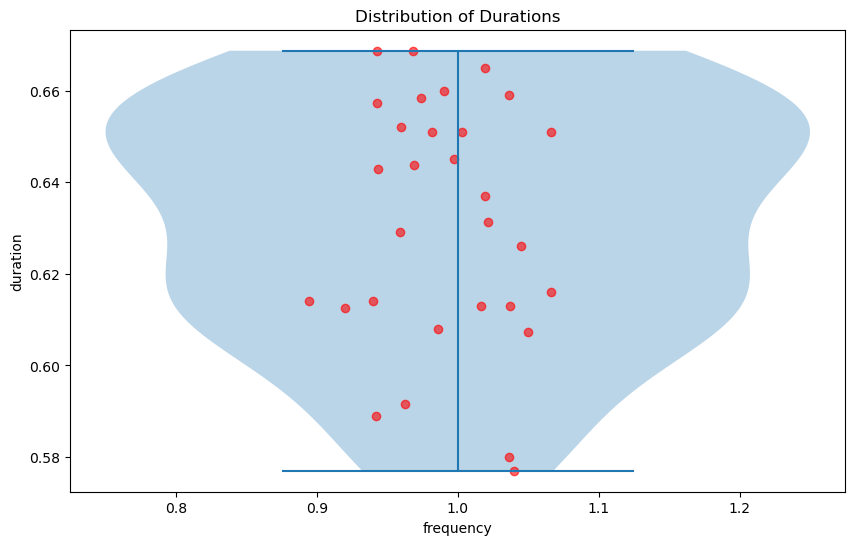

Statistics=0.938, p=0.082
Sample looks Gaussian (fail to reject H0)


>>>> exploring the durations across subject averaged gait cycles...
[0.6416666666666666, 0.651042, 0.6123333333333334, 0.6560000000000001, 0.6136666666666667, 0.6566666666666667, 0.582, 0.6590276666666667, 0.634722, 0.6038193333333333]


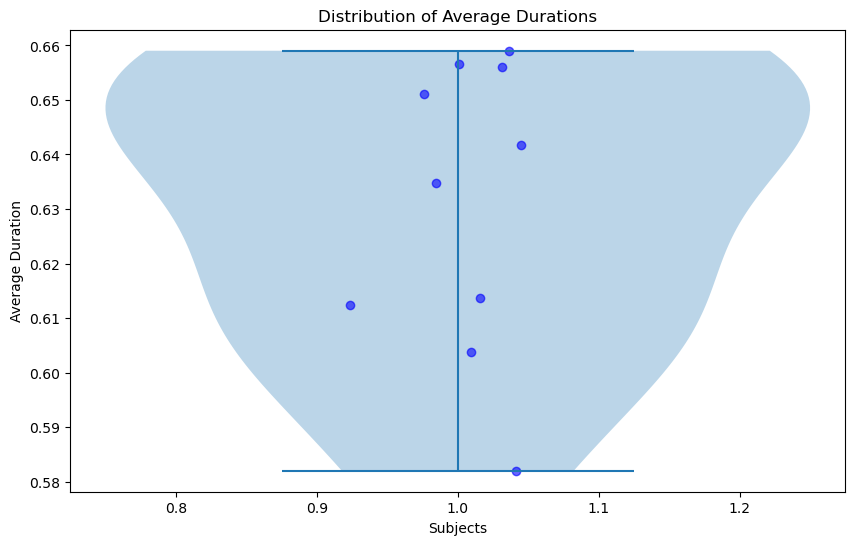

Statistics (avg)=0.900, p (avg)=0.217
Average durations look Gaussian (fail to reject H0)
Overall Average Duration: 0.631
Overall Standard Deviation of Durations: 0.025


In [54]:
from scipy.stats import shapiro
print('>>>> exploring all the durations of multiple gait cycles and subjects...')
print(durations)
print(durations['duration'].shape)
import matplotlib.pyplot as plt

# Flatten the durations data
durations_flat = durations['duration'].flatten()

# Create a violin plot for the durations data
plt.figure(figsize=(10, 6))
plt.violinplot(durations_flat)

# Add jittered individual data points
x = np.random.normal(1, 0.04, size=len(durations_flat))  # Adding jitter
plt.scatter(x, durations_flat, alpha=0.6, color='red')

plt.title('Distribution of Durations')
plt.xlabel('frequency')
plt.ylabel('duration')
plt.show()


# Test for normality
stat, p = shapiro(durations_flat)
print('Statistics=%.3f, p=%.3f' % (stat, p))

# Interpret the result
alpha = 0.05
if p > alpha:
    print('Sample looks Gaussian (fail to reject H0)')
else:
    print('Sample does not look Gaussian (reject H0)')

##################
print('\n\n>>>> exploring the durations across subject averaged gait cycles...')
print(durations['avg'])
# Create a violin plot for the average durations data
plt.figure(figsize=(10, 6))
plt.violinplot(durations['avg'])

# Add jittered individual data points
x_avg = np.random.normal(1, 0.04, size=len(durations['avg']))  # Adding jitter
plt.scatter(x_avg, durations['avg'], alpha=0.6, color='blue')

plt.title('Distribution of Average Durations')
plt.xlabel('Subjects')
plt.ylabel('Average Duration')
plt.show()

# Test for normality on average durations
stat_avg, p_avg = shapiro(durations['avg'])
print('Statistics (avg)=%.3f, p (avg)=%.3f' % (stat_avg, p_avg))

# Interpret the result for average durations
if p_avg > alpha:
    print('Average durations look Gaussian (fail to reject H0)')
else:
    print('Average durations do not look Gaussian (reject H0)')

# Calculate the overall average and standard deviation of the average durations
overall_avg_duration = np.mean(durations['avg'])
overall_std_duration = np.std(durations['avg'])

# # Calculate the overall average and standard deviation of the standard deviations of durations
# overall_avg_stdev = np.mean(durations['stdev'])
# overall_std_stdev = np.std(durations['stdev'])

print(f'Overall Average Duration: {overall_avg_duration:.3f}')
print(f'Overall Standard Deviation of Durations: {overall_std_duration:.3f}')
# print(f'Overall Average of Standard Deviations: {overall_avg_stdev:.3f}')
# print(f'Overall Standard Deviation of Standard Deviations: {overall_std_stdev:.3f}')

In [51]:
# take a look at the general sizes of the population data to make sure we have everyone in attendance. 
# print(grfs.keys())
# print(grfs['ground_force_vy'].shape)
# print(kinematics.keys())
# print(kinematics['hip_flexion_r'].shape)
print(moments.keys())
# print(moments['hip_flexion_r'].shape)
if not (grfs['ground_force_vy'].shape[1] == 10 and kinematics['hip_flexion_r'].shape[1] == 10 and moments['hip_flexion_r'].shape[1] == 10):
    print('Not all subjects are present in the data')
    raise Exception('Data validation failed: Not all subjects are present in the data')
else:
    print('All subjects are present in the data')

dict_keys(['time', 'FX', 'FY', 'FZ', 'MX', 'MY', 'MZ', 'hip_flexion_r', 'hip_adduction_r', 'hip_rotation_r', 'knee_angle_r', 'ankle_angle_r', 'hip_flexion_l', 'hip_adduction_l', 'hip_rotation_l', 'knee_angle_l', 'ankle_angle_l', 'lumbar_extension', 'lumbar_bending', 'lumbar_rotation', 'arm_flex_r', 'arm_add_r', 'arm_rot_r', 'elbow_flex_r', 'pro_sup_r', 'arm_flex_l', 'arm_add_l', 'arm_rot_l', 'elbow_flex_l', 'pro_sup_l'])
All subjects are present in the data


In [16]:
# directory to save the data
savedir = 'C:\\Users\\jonstingel\\code\\predictiveSim\\testingMaterials\\PredictRunning_2d\\'
# trim out any of the columns and rename as needed for easy matching with my study

## start with GRF 
grf4means = pd.DataFrame()
grf4stds = pd.DataFrame()
for gr in grfs.keys():
    # print(gr)
    # get a sample population mean
    mean = np.mean(grfs[gr], axis=1)
    stdev = np.std(grfs[gr], axis=1)
    # save the mean and stdev to the dataframe
    grf4means[gr] = mean
    grf4stds[gr] = stdev
# save the grf data to a csv
grf4means.to_csv(savedir + 'Hamner4GRFMeans.csv', index=False)
grf4stds.to_csv(savedir + 'Hamner4GRFStds.csv', index=False)

## now do the kinematics.
kin4means = pd.DataFrame()
kin4stds = pd.DataFrame()
for kin in kinematics.keys():
    # print(kin)
    # get a sample population mean
    mean = np.mean(kinematics[kin], axis=1)
    stdev = np.std(kinematics[kin], axis=1)
    # save the mean and stdev to the dataframe
    kin4means[kin] = mean
    kin4stds[kin] = stdev
# save the kinematics data to a csv
kin4means.to_csv(savedir + 'Hamner4KinMeans.csv', index=False)
kin4stds.to_csv(savedir + 'Hamner4KinStds.csv', index=False)

## now do the moments
mom4means = pd.DataFrame()
mom4stds = pd.DataFrame()
for mom in moments.keys():
    # print(mom)
    if 'FX' not in mom and 'FY' not in mom and 'FZ' not in mom and 'MX' not in mom and 'MY' not in mom and 'MZ' not in mom:
        momentname = mom + '_moment'
        # get a sample population mean
        mean = np.mean(moments[mom], axis=1)
        stdev = np.std(moments[mom], axis=1)
        # save the mean and stdev to the dataframe
        mom4means[momentname] = mean
        mom4stds[momentname] = stdev
# save the moments data to a csv
mom4means.to_csv(savedir + 'Hamner4MomMeans.csv', index=False)
mom4stds.to_csv(savedir + 'Hamner4MomStds.csv', index=False)



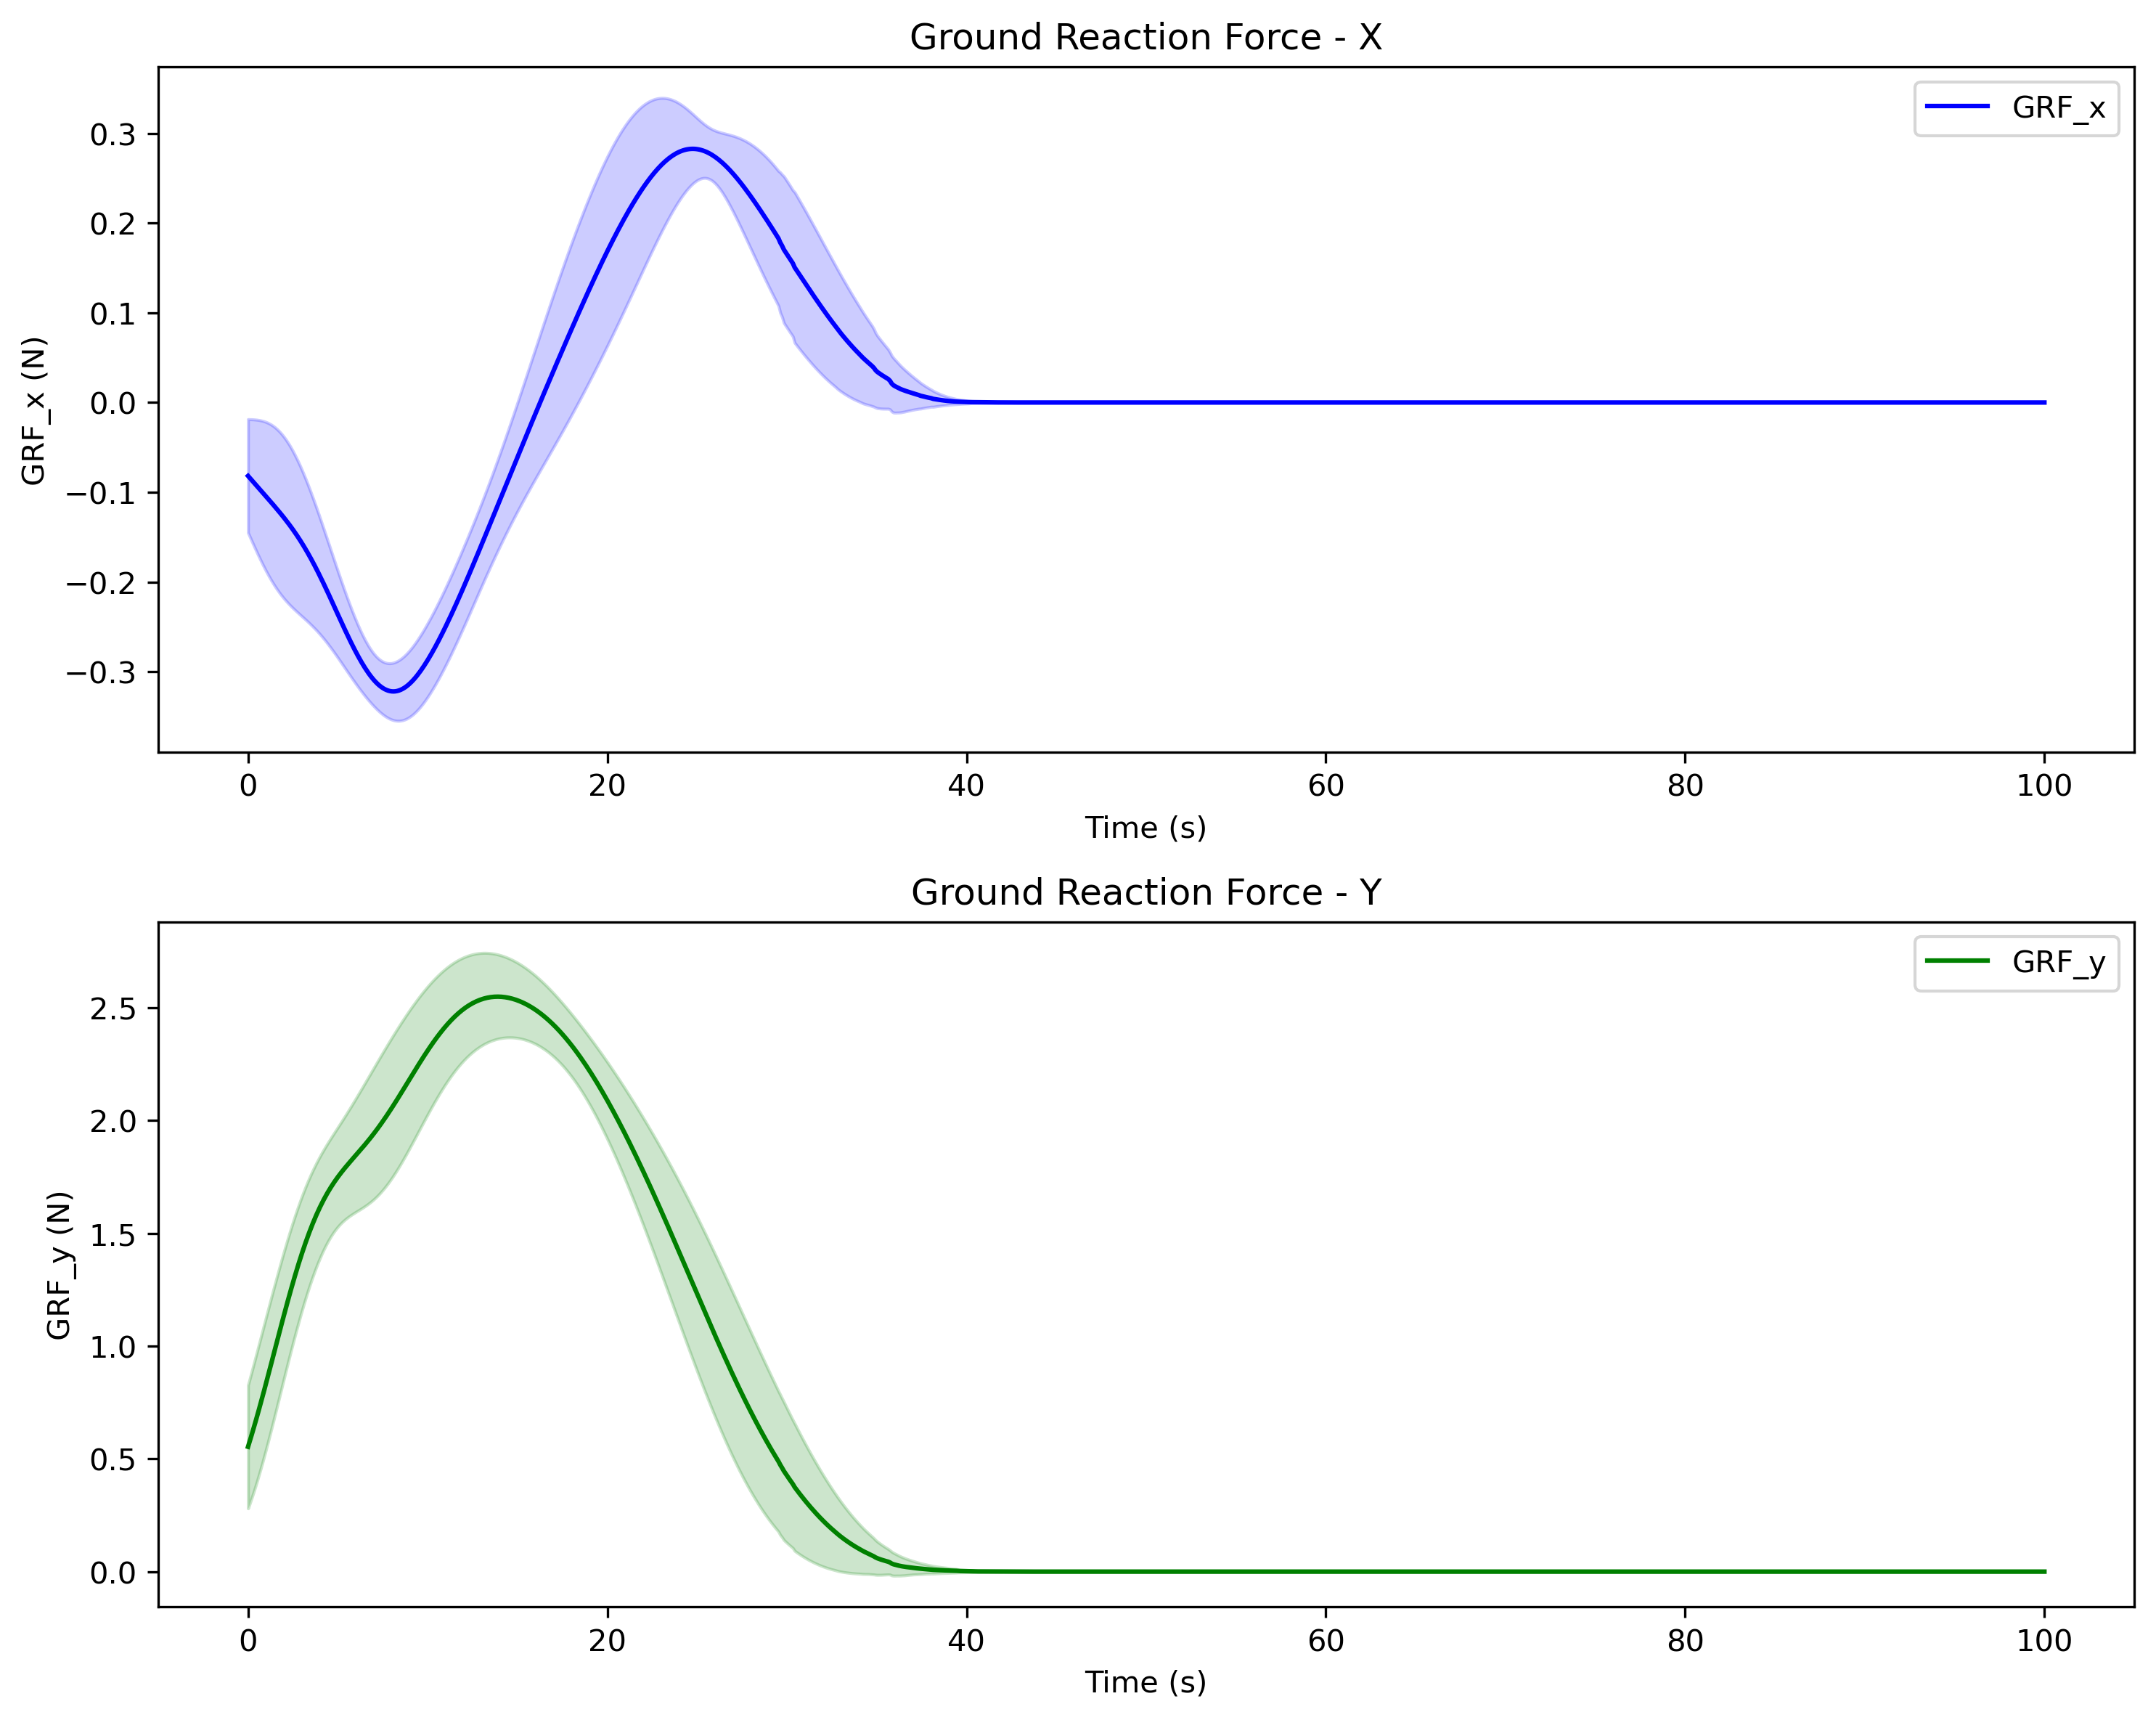

In [17]:
import matplotlib.pyplot as plt
# Create a figure with two subplots
fig, ax = plt.subplots(2, 1, figsize=(10, 8), dpi=300)

# Plot the x values in the first subplot
ax[0].plot(grf4means['time'], grf4means['ground_force_vx'], label='GRF_x', color='blue')
ax[0].fill_between(grf4means['time'], grf4means['ground_force_vx'] - grf4stds['ground_force_vx'], grf4means['ground_force_vx'] + grf4stds['ground_force_vx'], color='blue', alpha=0.2)
ax[0].set_title('Ground Reaction Force - X')
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('GRF_x (N)')
ax[0].legend()

# Plot the y values in the second subplot
ax[1].plot(grf4means['time'], grf4means['ground_force_vy'], label='GRF_y', color='green')
ax[1].fill_between(grf4means['time'], grf4means['ground_force_vy'] - grf4stds['ground_force_vy'], grf4means['ground_force_vy'] + grf4stds['ground_force_vy'], color='green', alpha=0.2)
ax[1].set_title('Ground Reaction Force - Y')
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('GRF_y (N)')
ax[1].legend()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()